In [1]:
!pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   -------- ------------------------------- 16.0/72.0 MB 81.0 MB/s eta 0:00:01
   ------------------ --------------------- 34.1/72.0 MB 85.4 MB/s eta 0:00:01
   ------------------------------ --------- 54.5/72.0 MB 87.2 MB/s eta 0:00:01
   ---------------------------------------  71.8/72.0 MB 89.2 MB/s eta 0:00:01
   ---------------------------------------- 72.0/72.0 MB 68.8 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import seaborn as sns 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
#loading data
df = pd.read_csv("Foreign_Exchange_Rates.xls")
df.head()

,Unnamed: 0,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,...,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$,Unnamed: 24
0,0,03-01-2000,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,...,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97,NaN
1,1,04-01-2000,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,...,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13,NaN
2,2,05-01-2000,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,...,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1,NaN
3,3,06-01-2000,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,...,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62,NaN
4,4,07-01-2000,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,...,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3,NaN


In [4]:
#Checking for missing values 
print('\nMissing Values:')
print(df.isnull().sum()) 


Missing Values:
Unnamed: 0                                      0
Time Serie                                      0
AUSTRALIA - AUSTRALIAN DOLLAR/US$               0
EURO AREA - EURO/US$                            0
NEW ZEALAND - NEW ZELAND DOLLAR/US$             0
UNITED KINGDOM - UNITED KINGDOM POUND/US$       0
BRAZIL - REAL/US$                               0
CANADA - CANADIAN DOLLAR/US$                    0
CHINA - YUAN/US$                                0
HONG KONG - HONG KONG DOLLAR/US$                0
INDIA - INDIAN RUPEE/US$                        0
KOREA - WON/US$                                 0
MEXICO - MEXICAN PESO/US$                       0
SOUTH AFRICA - RAND/US$                         0
SINGAPORE - SINGAPORE DOLLAR/US$                0
DENMARK - DANISH KRONE/US$                      0
JAPAN - YEN/US$                                 0
MALAYSIA - RINGGIT/US$                          0
NORWAY - NORWEGIAN KRONE/US$                    0
SWEDEN - KRONA/US$               

In [5]:
#dropping unneccessary columns and missing values
df = df.drop(columns=['Unnamed: 0', 'Unnamed: 24'])
df.head()

,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,INDIA - INDIAN RUPEE/US$,...,SINGAPORE - SINGAPORE DOLLAR/US$,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$
0,03-01-2000,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,43.55,...,1.6563,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97
1,04-01-2000,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,43.55,...,1.6535,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13
2,05-01-2000,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,43.55,...,1.656,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1
3,06-01-2000,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,43.55,...,1.6655,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62
4,07-01-2000,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,43.55,...,1.6625,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3


In [6]:
#dropping null values and converting timeseries to datetime 
df = df.dropna()
df['Time Serie'] = pd.to_datetime(df['Time Serie'], format='%d-%m-%Y')
df.head()

,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,INDIA - INDIAN RUPEE/US$,...,SINGAPORE - SINGAPORE DOLLAR/US$,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$
0,2000-01-03,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,43.55,...,1.6563,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97
1,2000-01-04,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,43.55,...,1.6535,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13
2,2000-01-05,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,43.55,...,1.656,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1
3,2000-01-06,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,43.55,...,1.6655,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62
4,2000-01-07,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,43.55,...,1.6625,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3


In [7]:
#sorting time-series by time order 
df = df.sort_values('Time Serie')
time_col = 'Time Serie'

In [8]:
#converting data in columns (except Time Serie) into numeric data (not object, str) 
df[df.columns.difference([time_col])] = df[df.columns.difference([time_col])].apply(pd.to_numeric, errors='coerce')
#handling any new missing values 
df=df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5015 entries, 0 to 5216
Data columns (total 23 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Time Serie                                 5015 non-null   datetime64[ns]
 1   AUSTRALIA - AUSTRALIAN DOLLAR/US$          5015 non-null   float64       
 2   EURO AREA - EURO/US$                       5015 non-null   float64       
 3   NEW ZEALAND - NEW ZELAND DOLLAR/US$        5015 non-null   float64       
 4   UNITED KINGDOM - UNITED KINGDOM POUND/US$  5015 non-null   float64       
 5   BRAZIL - REAL/US$                          5015 non-null   float64       
 6   CANADA - CANADIAN DOLLAR/US$               5015 non-null   float64       
 7   CHINA - YUAN/US$                           5015 non-null   float64       
 8   HONG KONG - HONG KONG DOLLAR/US$           5015 non-null   float64       
 9   INDIA - INDIAN RUPEE/US$

In [23]:
def xgboost(
    df,
    currency,
    n_lags=30,
    plot=True
):
    from xgboost import XGBRegressor 

    #data preparation 
    #extracting the series 
    series = df[currency].copy()
    total_rows = len(series)

    #splitting train/test/validation
    total_rows = len(series)
    train_end = int(0.7 * total_rows)
    val_end = int(0.8 * total_rows)
    train = series.iloc[:train_end]
    val = series.iloc[train_end:val_end]
    test = series.iloc[val_end:]

    #creating lag features function (come back to this)
    def lag_feat(data_series, full_series, n_lags):
        df = pd.DataFrame(index=data_series.index)
        for lag in range(1, n_lags+1):
            df[f'lag_{lag}'] = full_series.shift(lag).reindex(data_series.index)
        return df 

    #create features for train, val and test
    X_train = lag_feat(train, series, n_lags)
    X_val = lag_feat(val, series, n_lags)
    X_test = lag_feat(test, series, n_lags)

    #fill NaN values (forward then backward fill)
    X_train = X_train.ffill().bfill() 
    X_val = X_val.ffill().bfill()
    X_test = X_test.ffill().bfill()

    #target values 
    y_train = train.values
    y_val = val.values 
    y_test = test.values 

    #convert to numpy arrays 
    X_train_array = X_train.values 
    X_val_array = X_val.values 
    X_test_array = X_test.values

    print(f'Feature shape: {X_train_array.shape}')

    XGB = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=20,
        eval_metric='mae'
    )

    #fitting the model with validation
    print('Training XGBoose model...')
    XGB.fit(
        X_train_array, y_train,
        eval_set=[(X_val_array, y_val)],
        verbose=False
    )

    #predictions on test set
    y_pred = XGB.predict(X_test_array)

    #calculating metrics on test set
    from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100 
    y_val_pred = XGB.predict(X_val_array)
    mae_val = mean_absolute_error(y_val, y_val_pred)

    #printing results 
    results = {
        'model_name': 'XGBoost',
        'model': XGB,
        'predictions': y_pred,
        'actual': y_test,
        'test_dates': test.index,
        'metrics': {
            'MAE': mae,
            'RMSE': rmse,
            'MAPE': mape,
            'MAE_val': mae_val
        }
    }

    print(f"\nTest Metrics:")
    print(f"  MAE:  {mae:.6f}")
    print(f"  RMSE: {rmse:.6f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"Validation MAE: {mae_val:.6f}")

    #plotting 
    plt.figure(figsize=(14, 6))
        
    # Plot actual values
    plt.plot(test.index, y_test, 'k-', linewidth=2, label='Actual (Test Set)', alpha=0.8)
        
    # Plot predictions
    plt.plot(test.index, y_pred, 'r--', linewidth=2, label='XGBoost Predictions', alpha=0.8)
    
    return results

Feature shape: (3510, 30)
Training XGBoose model...

Test Metrics:
  MAE:  0.007301
  RMSE: 0.009398
  MAPE: 0.53%
Validation MAE: 0.007053


{'MAE': 0.007301099338512481,
 'RMSE': np.float64(0.00939755274892361),
 'MAPE': 0.5341451601976565,
 'MAE_val': 0.007053262233734126}

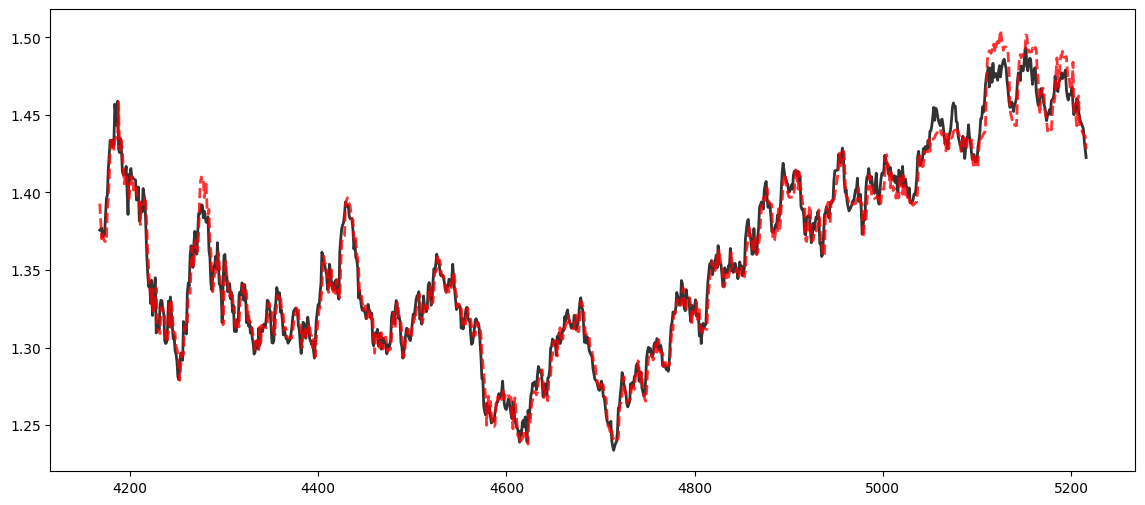

In [54]:
aus_xgb = xgboost(df, "AUSTRALIA - AUSTRALIAN DOLLAR/US$")

aus_xgb["metrics"]

Feature shape: (3510, 30)
Training XGBoose model...

Test Metrics:
  MAE:  0.003993
  RMSE: 0.005180
  MAPE: 0.45%
Validation MAE: 0.004492


{'MAE': 0.003992989802051516,
 'RMSE': np.float64(0.005179648895068506),
 'MAPE': 0.4501032040614614,
 'MAE_val': 0.004491967848857561}

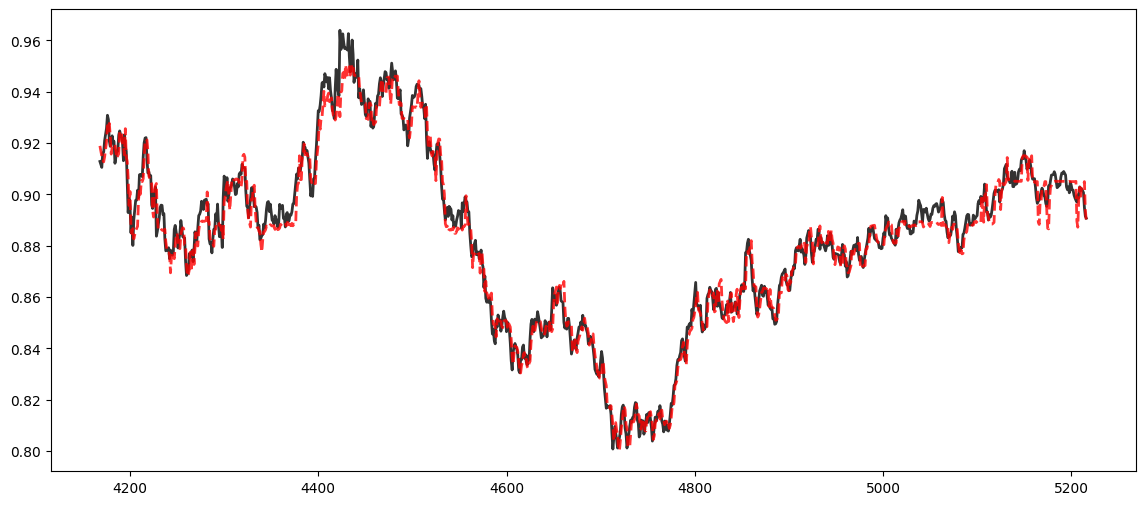

In [55]:
eur_xgb = xgboost(df, "EURO AREA - EURO/US$")

eur_xgb["metrics"]

Feature shape: (3510, 30)
Training XGBoose model...

Test Metrics:
  MAE:  0.007278
  RMSE: 0.009446
  MAPE: 0.50%
Validation MAE: 0.011080


{'MAE': 0.007278174079902626,
 'RMSE': np.float64(0.009446178282607754),
 'MAPE': 0.5014183198979911,
 'MAE_val': 0.011080030523733317}

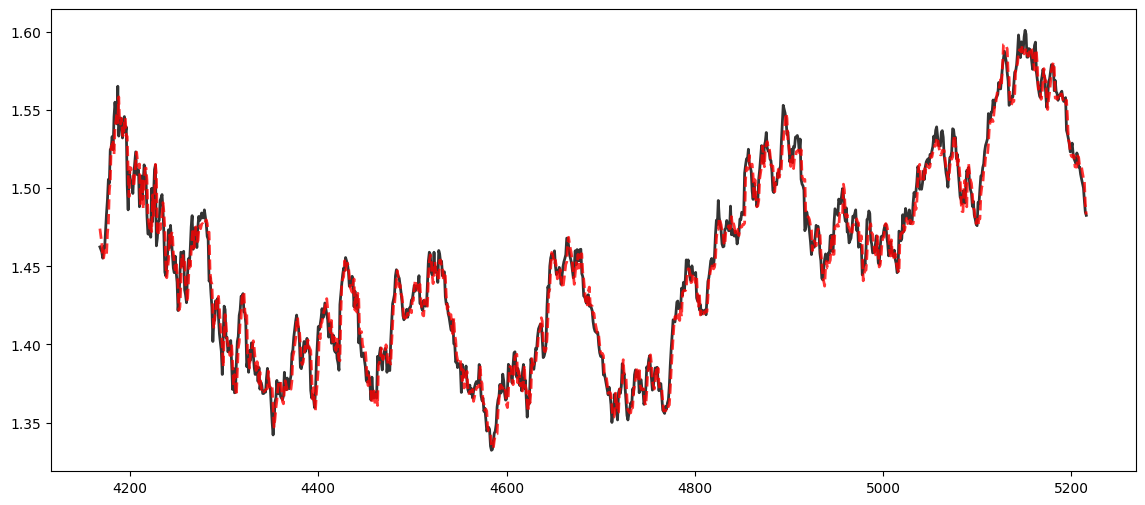

In [56]:
nz_xgb = xgboost(df, "NEW ZEALAND - NEW ZELAND DOLLAR/US$")

nz_xgb["metrics"]

Feature shape: (3510, 30)
Training XGBoose model...

Test Metrics:
  MAE:  0.058010
  RMSE: 0.066816
  MAPE: 7.42%
Validation MAE: 0.002573


{'MAE': 0.058009554143013765,
 'RMSE': np.float64(0.06681600788332609),
 'MAPE': 7.420373779418956,
 'MAE_val': 0.0025728007400178344}

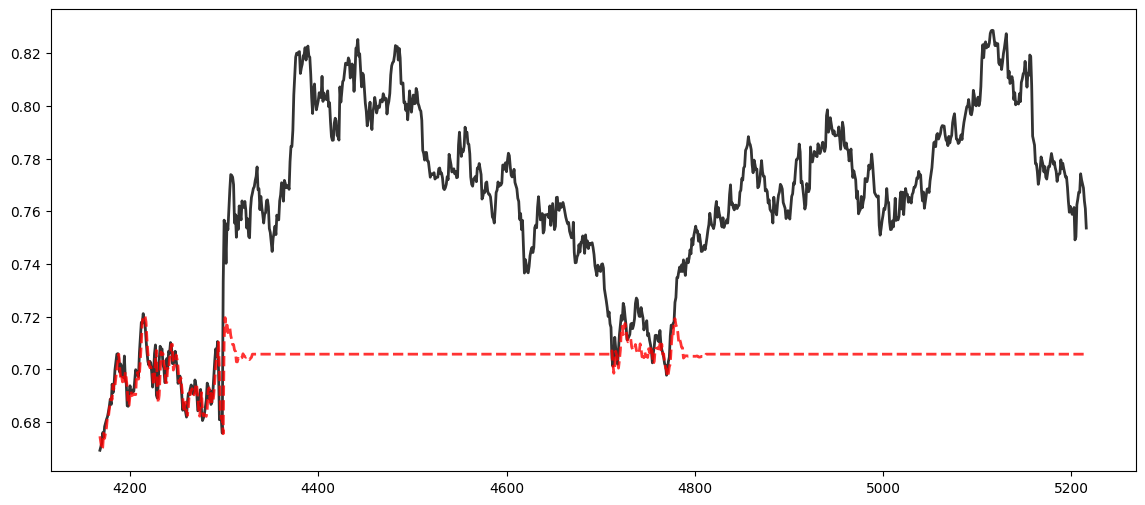

In [57]:
uk_xgb = xgboost(df, "UNITED KINGDOM - UNITED KINGDOM POUND/US$")

uk_xgb["metrics"]

Feature shape: (3510, 30)
Training XGBoose model...

Test Metrics:
  MAE:  0.130966
  RMSE: 0.201214
  MAPE: 3.38%
Validation MAE: 0.046105


{'MAE': 0.13096585095938987,
 'RMSE': np.float64(0.20121417913339254),
 'MAPE': 3.377319165646506,
 'MAE_val': 0.04610498065112596}

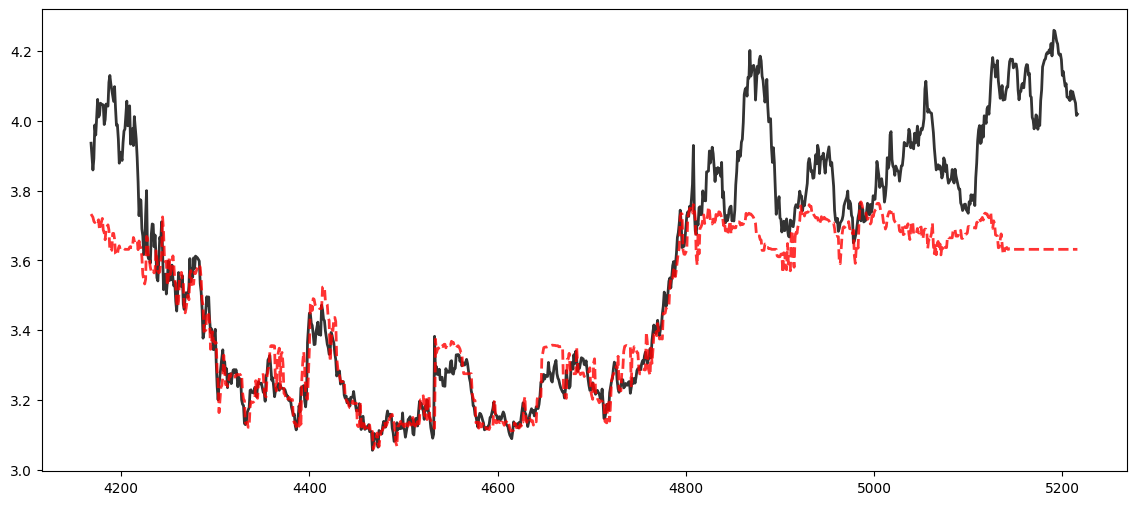

In [58]:
brz_xgb = xgboost(df, "BRAZIL - REAL/US$")

brz_xgb["metrics"]

Feature shape: (3510, 30)
Training XGBoose model...

Test Metrics:
  MAE:  0.005917
  RMSE: 0.007881
  MAPE: 0.45%
Validation MAE: 0.005968


{'MAE': 0.00591662552111883,
 'RMSE': np.float64(0.007880518551673028),
 'MAPE': 0.44993550131236726,
 'MAE_val': 0.005968282179813462}

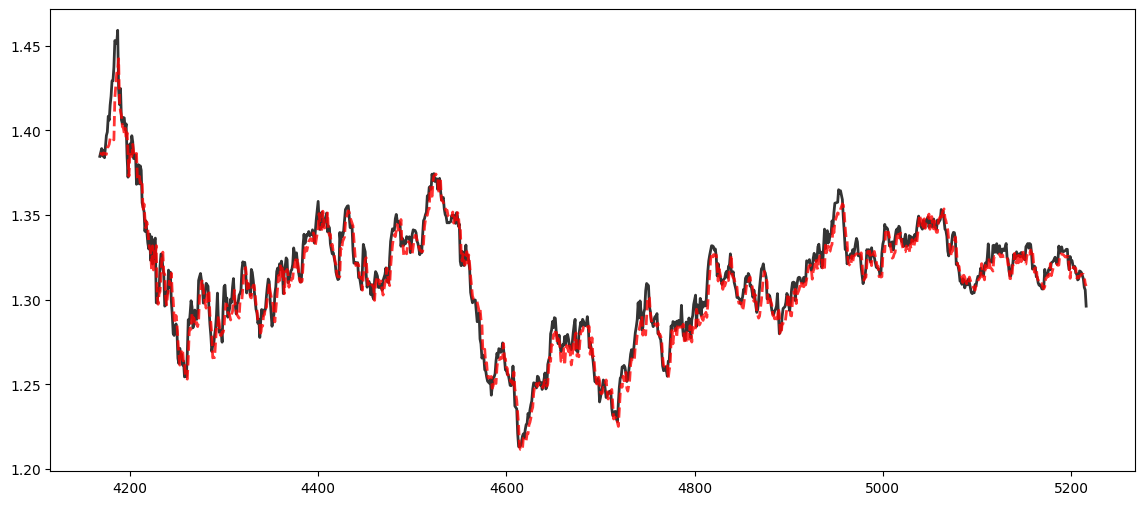

In [59]:
cnd_xgb = xgboost(df, "CANADA - CANADIAN DOLLAR/US$")

cnd_xgb["metrics"]

Feature shape: (3510, 30)
Training XGBoose model...

Test Metrics:
  MAE:  0.031712
  RMSE: 0.045190
  MAPE: 0.47%
Validation MAE: 0.016527


{'MAE': 0.03171238066729378,
 'RMSE': np.float64(0.04518971379766313),
 'MAPE': 0.4693240389268597,
 'MAE_val': 0.01652654001760295}

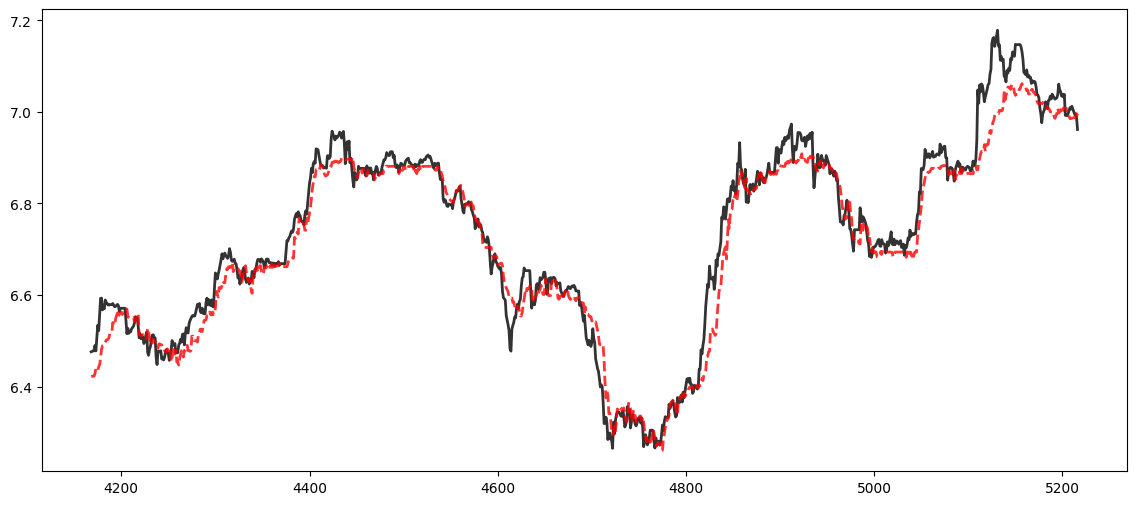

In [60]:
cny_xgb = xgboost(df, "CHINA - YUAN/US$")

cny_xgb["metrics"]

Feature shape: (3510, 30)
Training XGBoose model...

Test Metrics:
  MAE:  0.013934
  RMSE: 0.020760
  MAPE: 0.18%
Validation MAE: 0.000953


{'MAE': 0.013933641218830081,
 'RMSE': np.float64(0.02076008722111207),
 'MAPE': 0.17774862055139118,
 'MAE_val': 0.0009530058340247473}

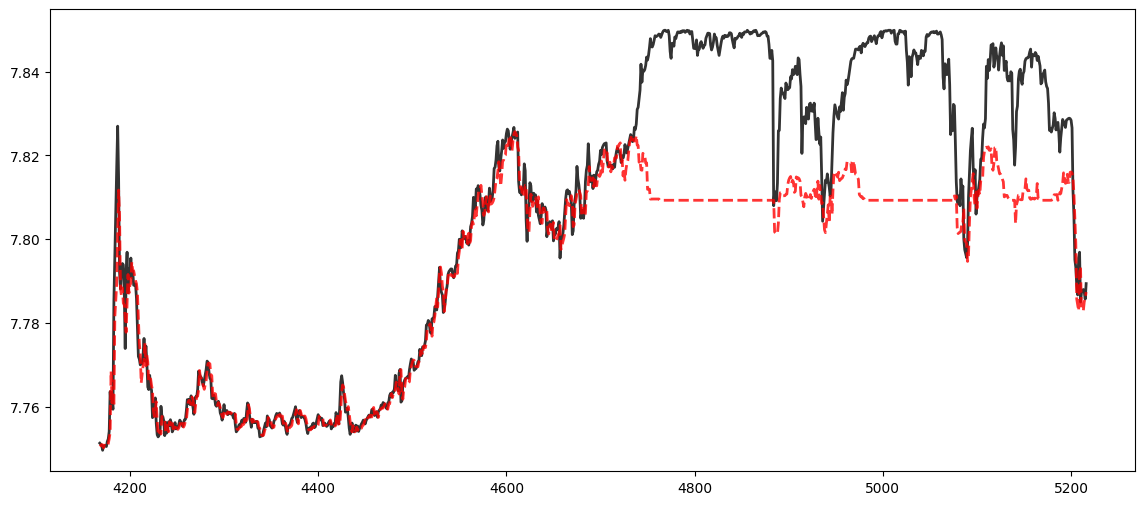

In [61]:
hkd_xgb = xgboost(df, "HONG KONG - HONG KONG DOLLAR/US$")

hkd_xgb["metrics"]

Feature shape: (3510, 30)
Training XGBoose model...

Test Metrics:
  MAE:  4.449190
  RMSE: 5.284316
  MAPE: 6.42%
Validation MAE: 0.757145


{'MAE': 4.449190206419316,
 'RMSE': np.float64(5.2843161228010285),
 'MAPE': 6.416486089724597,
 'MAE_val': 0.7571448479762588}

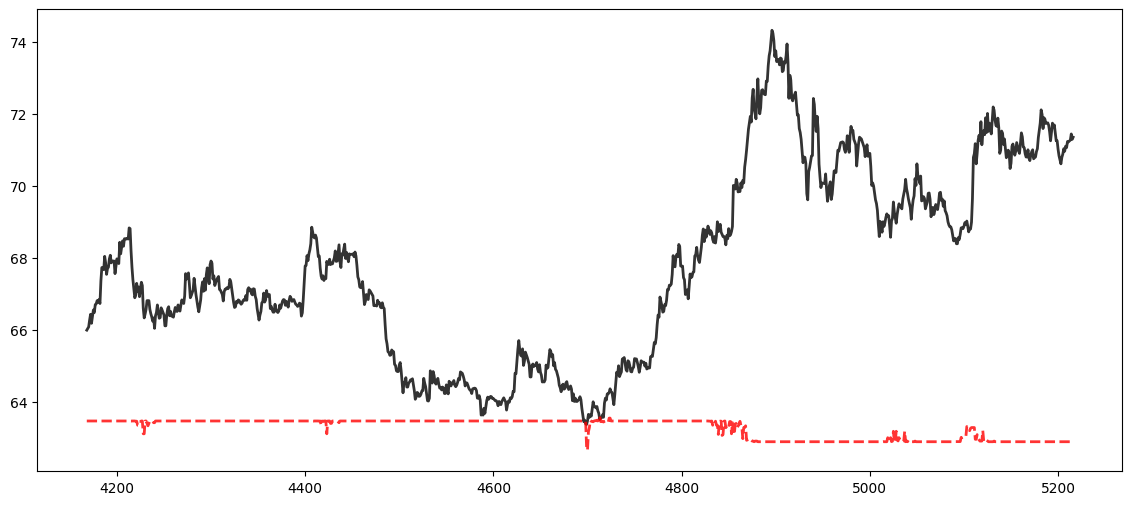

In [62]:
idr_xgb = xgboost(df, "INDIA - INDIAN RUPEE/US$")

idr_xgb["metrics"]

Feature shape: (3510, 30)
Training XGBoose model...

Test Metrics:
  MAE:  4.909046
  RMSE: 6.587312
  MAPE: 0.43%
Validation MAE: 5.083696


{'MAE': 4.909046064930205,
 'RMSE': np.float64(6.587311534882875),
 'MAPE': 0.43040666597791544,
 'MAE_val': 5.083695525515123}

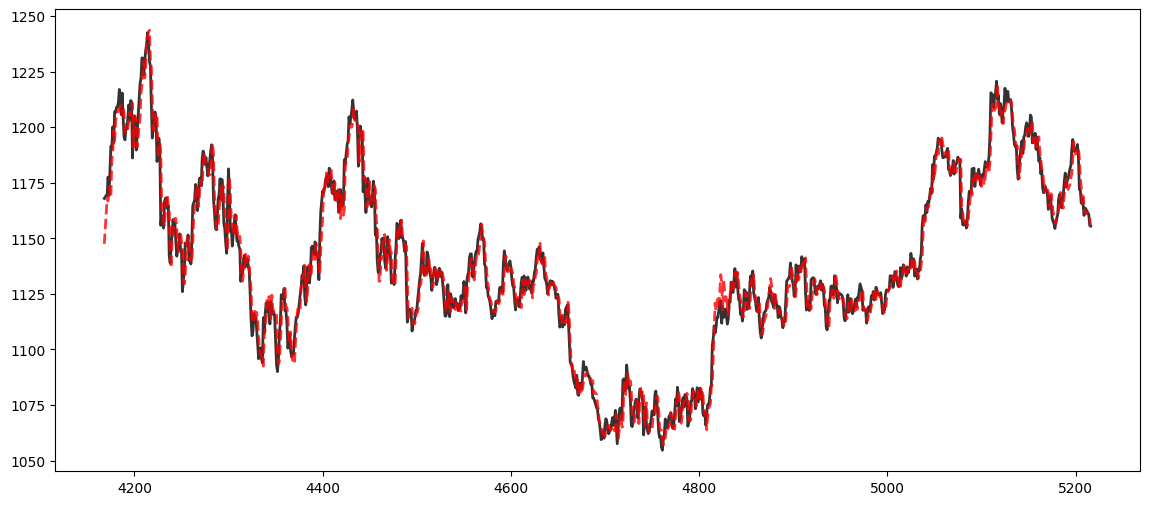

In [63]:
krw_xgb = xgboost(df, "KOREA - WON/US$")

krw_xgb["metrics"]

Feature shape: (3510, 30)
Training XGBoose model...

Test Metrics:
  MAE:  4.578684
  RMSE: 4.653208
  MAPE: 23.96%
Validation MAE: 0.708008


{'MAE': 4.578683781346391,
 'RMSE': np.float64(4.653208294818342),
 'MAPE': 23.962048491611935,
 'MAE_val': 0.7080079114450402}

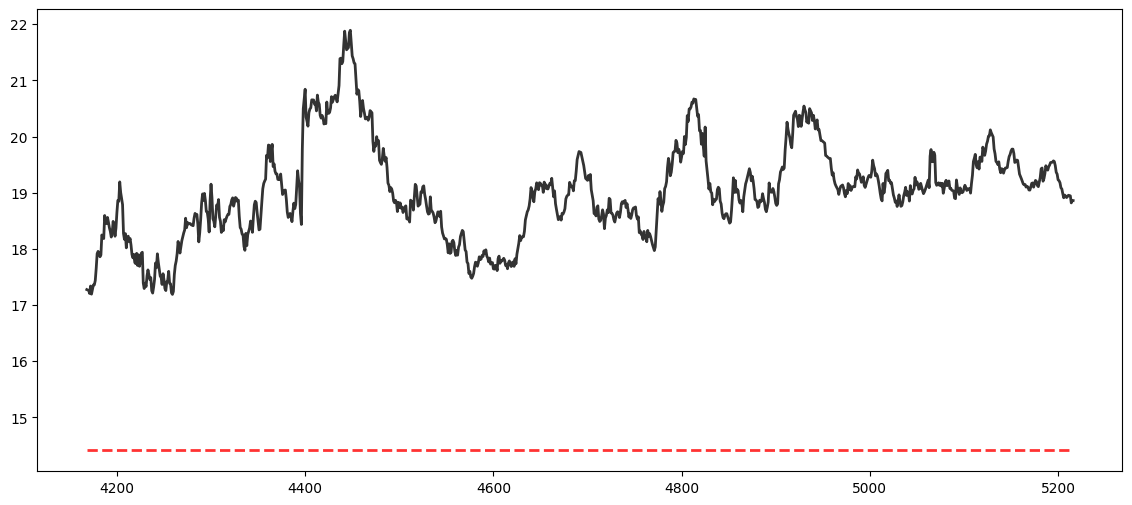

In [64]:
mxp_xgb = xgboost(df, "MEXICO - MEXICAN PESO/US$")

mxp_xgb["metrics"]

Feature shape: (3510, 30)
Training XGBoose model...

Test Metrics:
  MAE:  2.272032
  RMSE: 2.488684
  MAPE: 15.87%
Validation MAE: 0.568860


{'MAE': 2.272031600692004,
 'RMSE': np.float64(2.4886840472097735),
 'MAPE': 15.870991699521847,
 'MAE_val': 0.5688602021844262}

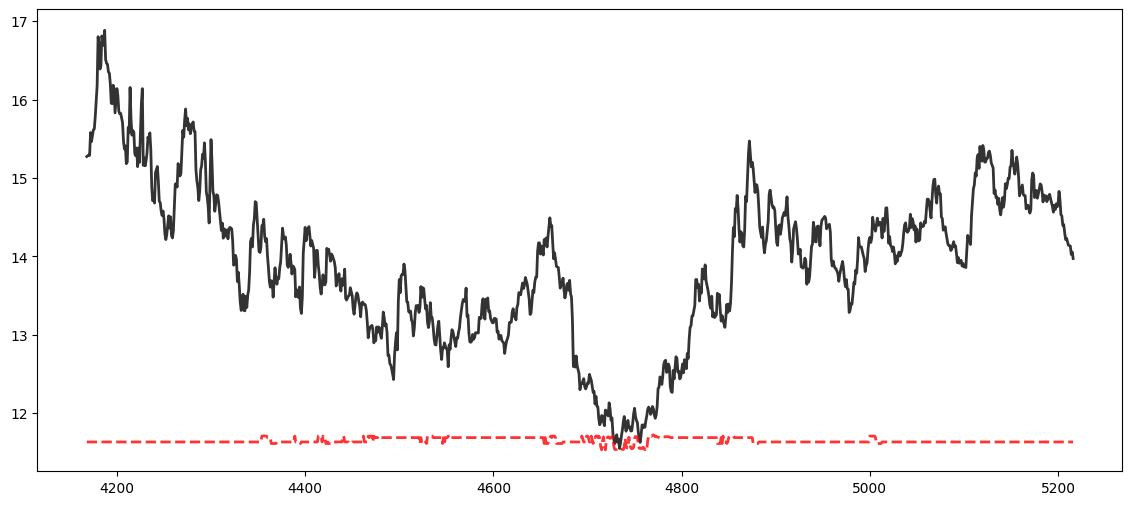

In [65]:
sar_xgb = xgboost(df, "SOUTH AFRICA - RAND/US$")

sar_xgb["metrics"]

Feature shape: (3510, 30)
Training XGBoose model...

Test Metrics:
  MAE:  0.004500
  RMSE: 0.006411
  MAPE: 0.33%
Validation MAE: 0.005004


{'MAE': 0.0045002199391662645,
 'RMSE': np.float64(0.0064106569825510135),
 'MAPE': 0.3297192308786617,
 'MAE_val': 0.00500389745643889}

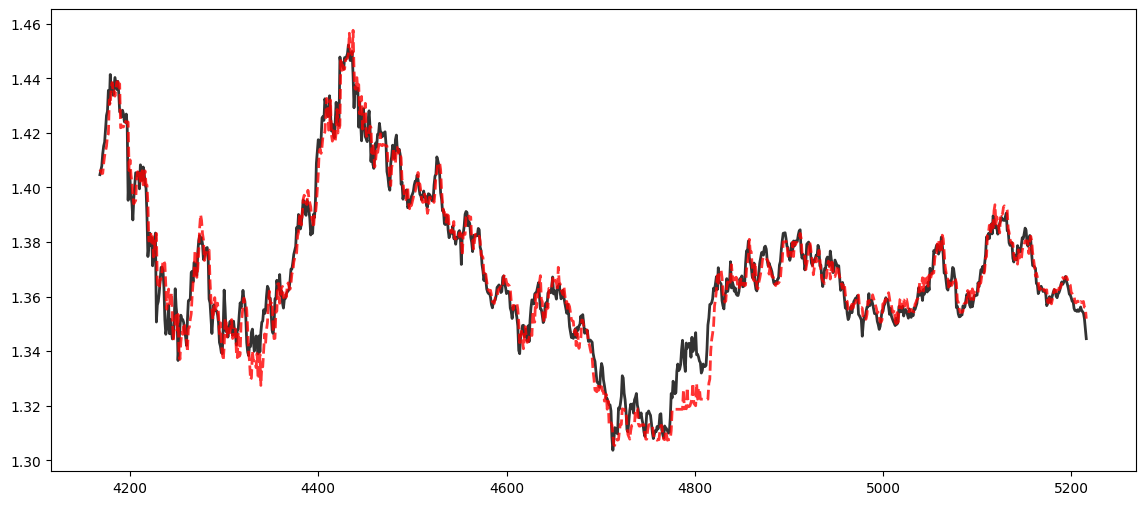

In [66]:
sgd_xgb = xgboost(df, "SINGAPORE - SINGAPORE DOLLAR/US$")
sgd_xgb["metrics"]

Feature shape: (3510, 30)
Training XGBoose model...

Test Metrics:
  MAE:  0.031767
  RMSE: 0.040806
  MAPE: 0.48%
Validation MAE: 0.033008


{'MAE': 0.0317673403815044,
 'RMSE': np.float64(0.04080641317492769),
 'MAPE': 0.4804444589985517,
 'MAE_val': 0.03300791024895781}

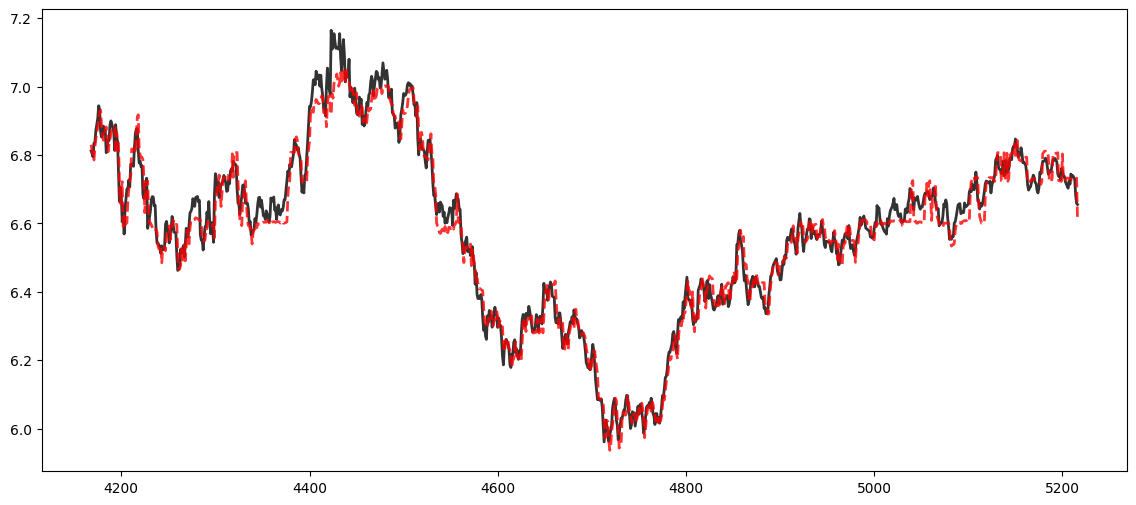

In [67]:
dnk_xgb = xgboost(df, "DENMARK - DANISH KRONE/US$")
dnk_xgb["metrics"]

Feature shape: (3510, 30)
Training XGBoose model...

Test Metrics:
  MAE:  0.476878
  RMSE: 0.668348
  MAPE: 0.43%
Validation MAE: 0.508196


{'MAE': 0.47687840135599047,
 'RMSE': np.float64(0.6683475078895235),
 'MAPE': 0.43427321145235886,
 'MAE_val': 0.5081960068660902}

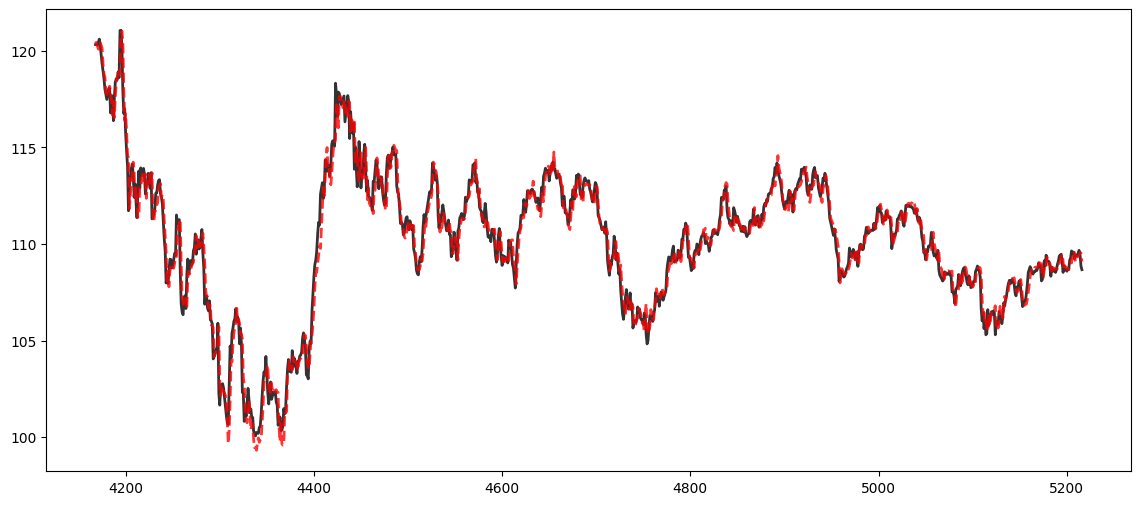

In [68]:
jpy_xgb = xgboost(df, "JAPAN - YEN/US$")
jpy_xgb["metrics"]

Feature shape: (3510, 30)
Training XGBoose model...

Test Metrics:
  MAE:  0.352746
  RMSE: 0.382979
  MAPE: 8.38%
Validation MAE: 0.097975


{'MAE': 0.35274645874844945,
 'RMSE': np.float64(0.3829789858132),
 'MAPE': 8.377449380310473,
 'MAE_val': 0.09797506801255669}

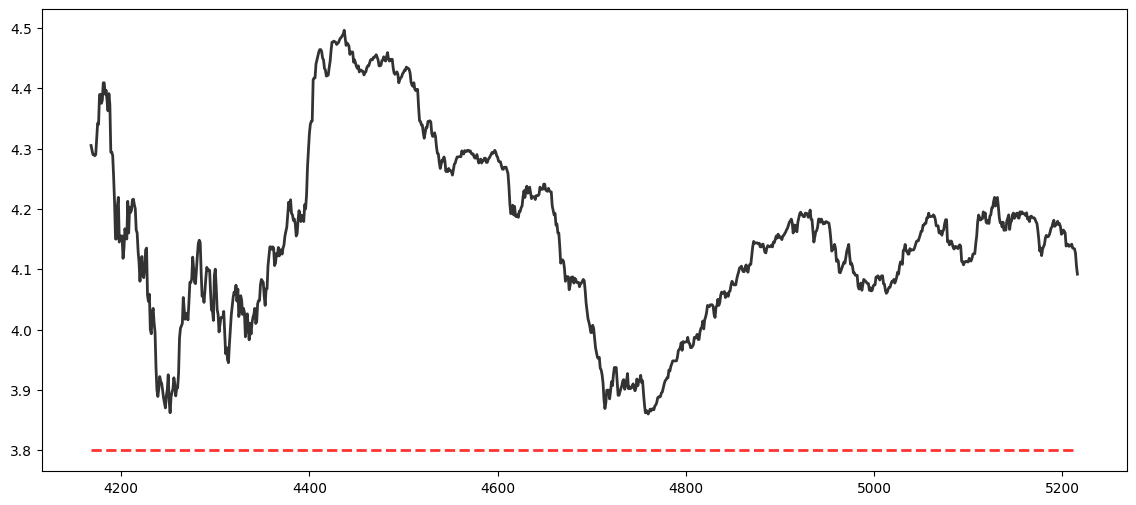

In [69]:
mlr_xgb = xgboost(df, "MALAYSIA - RINGGIT/US$")
mlr_xgb["metrics"]

Feature shape: (3510, 30)
Training XGBoose model...

Test Metrics:
  MAE:  0.056530
  RMSE: 0.074822
  MAPE: 0.68%
Validation MAE: 0.058020


{'MAE': 0.05652990647807555,
 'RMSE': np.float64(0.07482219032855875),
 'MAPE': 0.6826647017737959,
 'MAE_val': 0.05801950565201353}

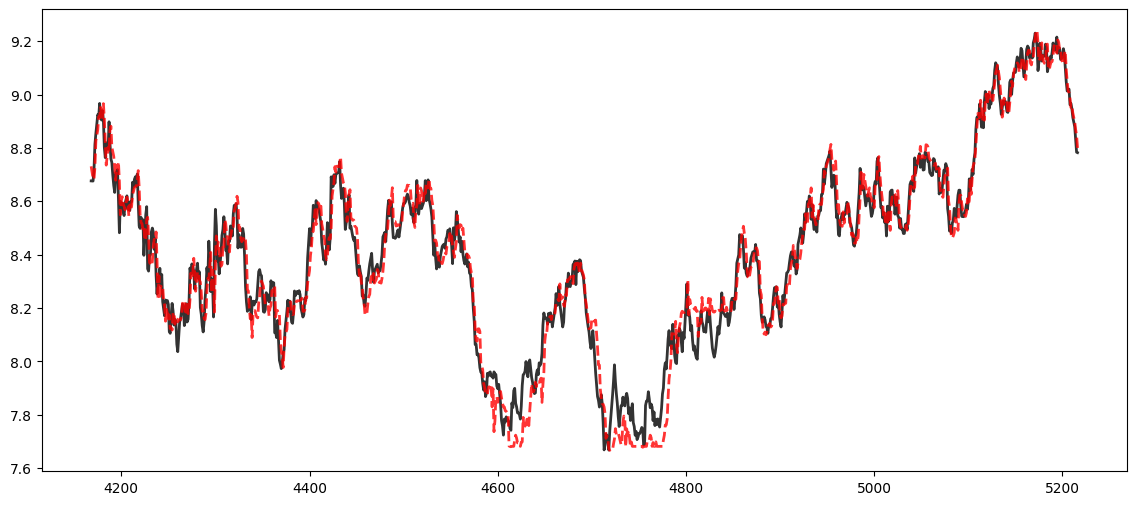

In [70]:
nrk_xgb = xgboost(df, "NORWAY - NORWEGIAN KRONE/US$")
nrk_xgb["metrics"]

Feature shape: (3510, 30)
Training XGBoose model...

Test Metrics:
  MAE:  0.044066
  RMSE: 0.056840
  MAPE: 0.50%
Validation MAE: 0.041465


{'MAE': 0.04406551143764143,
 'RMSE': np.float64(0.05684006740219517),
 'MAPE': 0.5014678953283602,
 'MAE_val': 0.04146491441764678}

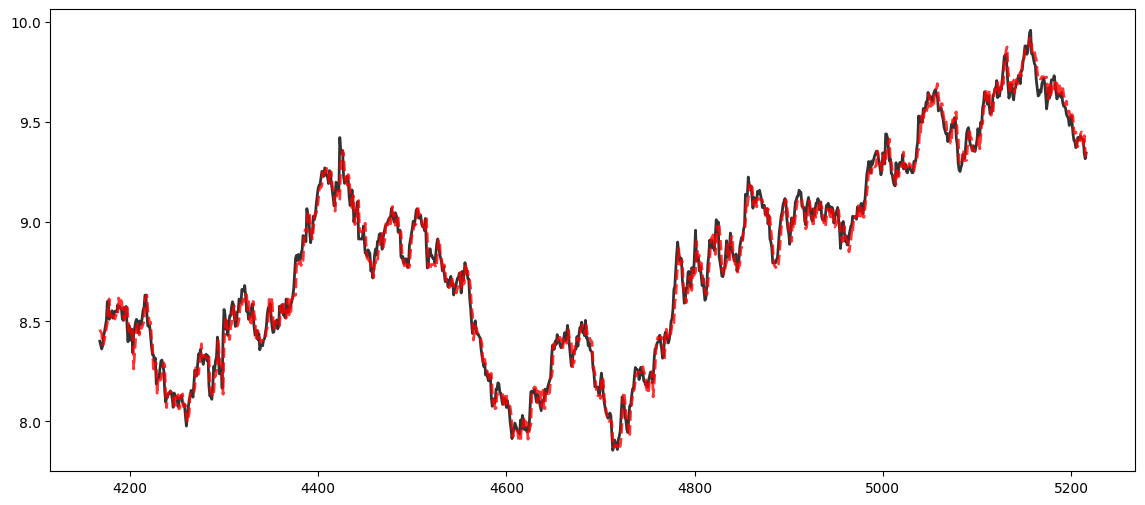

In [71]:
swk_xgb = xgboost(df, "SWEDEN - KRONA/US$")
swk_xgb["metrics"]

Feature shape: (3510, 30)
Training XGBoose model...

Test Metrics:
  MAE:  27.801567
  RMSE: 30.749606
  MAPE: 16.88%
Validation MAE: 1.744150


{'MAE': 27.80156701465428,
 'RMSE': np.float64(30.74960605926256),
 'MAPE': 16.87622314795179,
 'MAE_val': 1.7441504757337836}

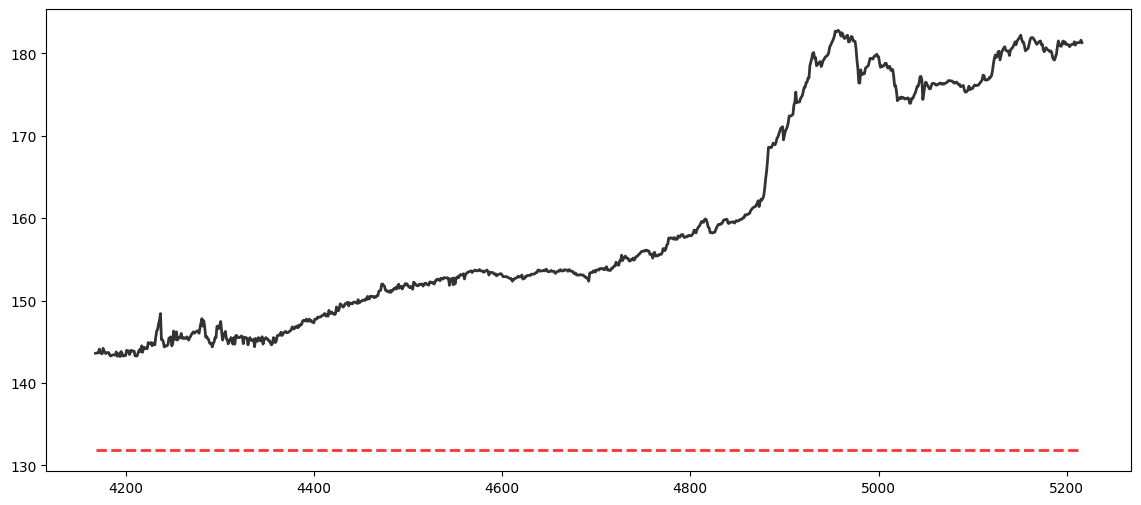

In [72]:
slr_xgb = xgboost(df, "SRI LANKA - SRI LANKAN RUPEE/US$")
slr_xgb["metrics"]

Feature shape: (3510, 30)
Training XGBoose model...

Test Metrics:
  MAE:  0.004059
  RMSE: 0.005247
  MAPE: 0.41%
Validation MAE: 0.005111


{'MAE': 0.004058601309414044,
 'RMSE': np.float64(0.00524736472979623),
 'MAPE': 0.4122346219931487,
 'MAE_val': 0.005110881334092035}

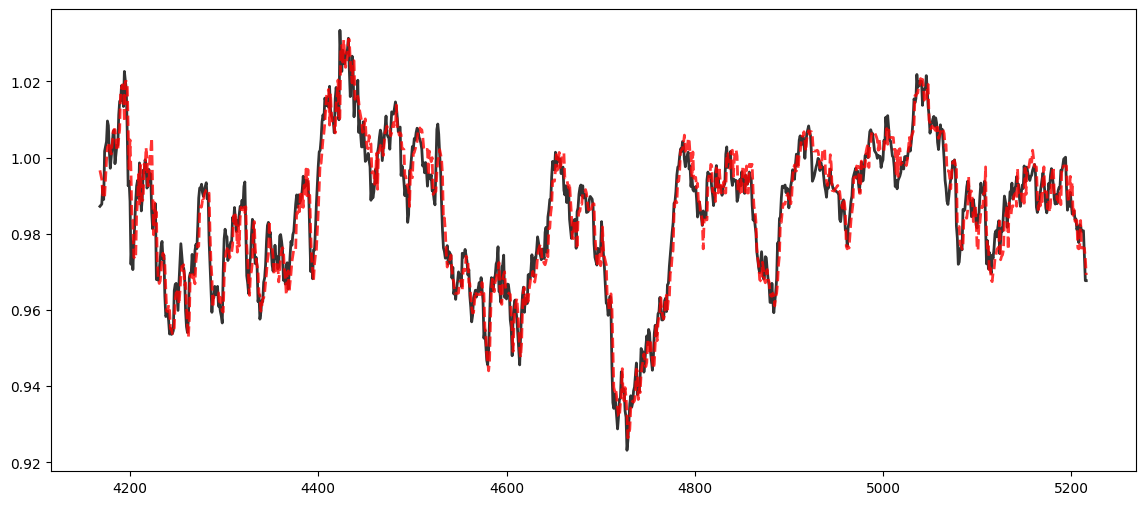

In [73]:
swf_xgb = xgboost(df, "SWITZERLAND - FRANC/US$")
swf_xgb["metrics"]

Feature shape: (3510, 30)
Training XGBoose model...

Test Metrics:
  MAE:  0.073941
  RMSE: 0.103911
  MAPE: 0.24%
Validation MAE: 0.078286


{'MAE': 0.07394066693656821,
 'RMSE': np.float64(0.10391129788700794),
 'MAPE': 0.23769236224492402,
 'MAE_val': 0.07828582398919945}

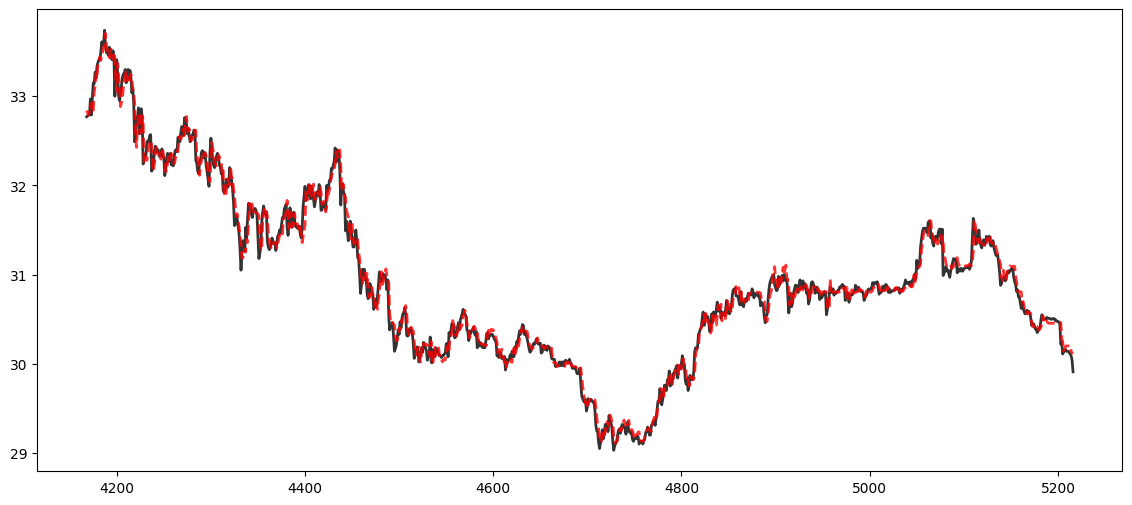

In [74]:
twd_xgb = xgboost(df, "TAIWAN - NEW TAIWAN DOLLAR/US$")
twd_xgb["metrics"]

Feature shape: (3510, 30)
Training XGBoose model...

Test Metrics:
  MAE:  0.090123
  RMSE: 0.119955
  MAPE: 0.27%
Validation MAE: 0.091068


{'MAE': 0.09012338723879632,
 'RMSE': np.float64(0.11995475395547754),
 'MAPE': 0.2706040104312043,
 'MAE_val': 0.09106794684056711}

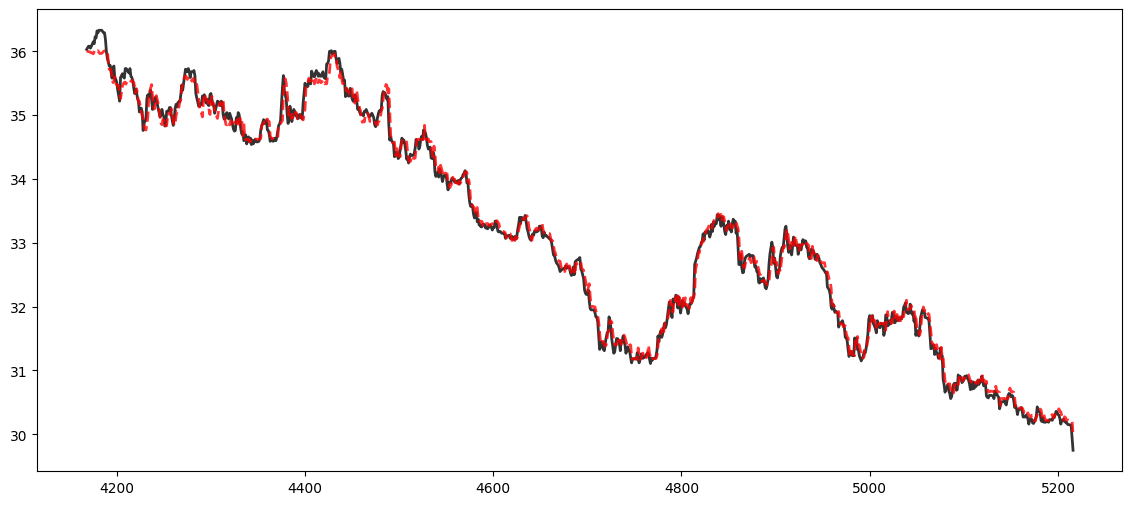

In [75]:
thb_xgb = xgboost(df, "THAILAND - BAHT/US$")
thb_xgb["metrics"]

In [76]:
#creating a folder 
import os
os.makedirs('models', exist_ok=True)

In [79]:
#using pickle to save models 
import pickle
with open('models/THB_XGB.pkl', 'wb') as f: #Thailand
    pickle.dump(thb_xgb['model'], f)

with open('models/TWD_XGB.pkl', 'wb') as f: #Taiwan
    pickle.dump(twd_xgb['model'], f)

with open('models/SWF_XGB.pkl', 'wb') as f: #Switzerland
    pickle.dump(swf_xgb['model'], f)

with open('models/SWK_XGB.pkl', 'wb') as f: #Sweden
    pickle.dump(swk_xgb['model'], f)

with open('models/NRK_XGB.pkl', 'wb') as f: #Norway
    pickle.dump(nrk_xgb['model'], f)

with open('models/JPY_XGB.pkl', 'wb') as f: #Japan
    pickle.dump(jpy_xgb['model'], f)

with open('models/DNK_XGB.pkl', 'wb') as f: #Denmark
    pickle.dump(dnk_xgb['model'], f)

with open('models/SGD_XGB.pkl', 'wb') as f: #Singapore
    pickle.dump(sgd_xgb['model'], f)

with open('models/KRW_XGB.pkl', 'wb') as f: #Korea
    pickle.dump(krw_xgb['model'], f)

with open('models/CNY_XGB.pkl', 'wb') as f: #China
    pickle.dump(cny_xgb['model'], f)

with open('models/CND_XGB.pkl', 'wb') as f: #Canada
    pickle.dump(cnd_xgb['model'], f)

with open('models/NZD_XGB.pkl', 'wb') as f: #New Zealand
    pickle.dump(nz_xgb['model'], f)

with open('models/EUR_XGB.pkl', 'wb') as f: #Euro
    pickle.dump(eur_xgb['model'], f)

with open('models/AUS_XGB.pkl', 'wb') as f: #Australia
    pickle.dump(aus_xgb['model'], f)


In [1]:
pip install xlrd

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install openpyxl


   ---------------------------------------- 0/2 [et-xmlfile]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [open


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
df = pd.read_excel("Foreign_Exchange_Rates.xlsx", header=None)

# Split the single column into real columns
df = df[0].str.split(",", expand=True)

# Use first row as header
df.columns = df.iloc[0]
df = df.drop(0).reset_index(drop=True)

# Rename the date column
df = df.rename(columns={"Time Serie": "Date"})

# Convert Date to datetime and set index
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
df = df.set_index("Date")

# Convert all currency columns to numeric
df = df.apply(pd.to_numeric, errors="coerce")

In [7]:
df.head()

,,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,INDIA - INDIAN RUPEE/US$,...,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$,
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,0,1.5172,0.9847,1.9033,0.6146,1.8050,1.4465,8.2798,7.7765,43.55,...,7.3290,101.70,3.8,7.964,8.4430,72.30,1.5808,31.38,36.97,NaN
2000-01-04,1,1.5239,0.9700,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,43.55,...,7.2180,103.09,3.8,7.934,8.3600,72.65,1.5565,30.60,37.13,NaN
2000-01-05,2,1.5267,0.9676,1.9339,0.6092,1.8560,1.4518,8.2798,7.7780,43.55,...,7.2080,103.77,3.8,7.935,8.3530,72.95,1.5526,30.80,37.10,NaN
2000-01-06,3,1.5291,0.9686,1.9436,0.6070,1.8400,1.4571,8.2797,7.7785,43.55,...,7.2125,105.19,3.8,7.940,8.3675,72.95,1.5540,31.75,37.62,NaN
2000-01-07,4,1.5272,0.9714,1.9380,0.6104,1.8310,1.4505,8.2794,7.7783,43.55,...,7.2285,105.17,3.8,7.966,8.4150,73.15,1.5623,30.85,37.30,NaN


## Naive baseline ("tomorrow = today")
Exchange rates are close to a random walk, so a model only adds value if it beats this baseline. Uses the same test window as `xgboost()` (the last 20% of rows). Compare `naive_MAPE_%` with each XGBoost test MAPE above.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

rows = []
for col in df.select_dtypes('number').columns:
    s = df[col].astype(float)
    val_end = int(0.8 * len(s))                  # same split as xgboost()
    test, naive = s.iloc[val_end:], s.shift(1).iloc[val_end:]   # naive forecast = previous day's rate
    rows.append({'currency': col,
                 'naive_MAE': mean_absolute_error(test, naive),
                 'naive_MAPE_%': mean_absolute_percentage_error(test, naive) * 100})
naive_results = pd.DataFrame(rows).set_index('currency').round(4)
naive_results